### Psychometric function
Edit the numbers marked `👈` and re-run.

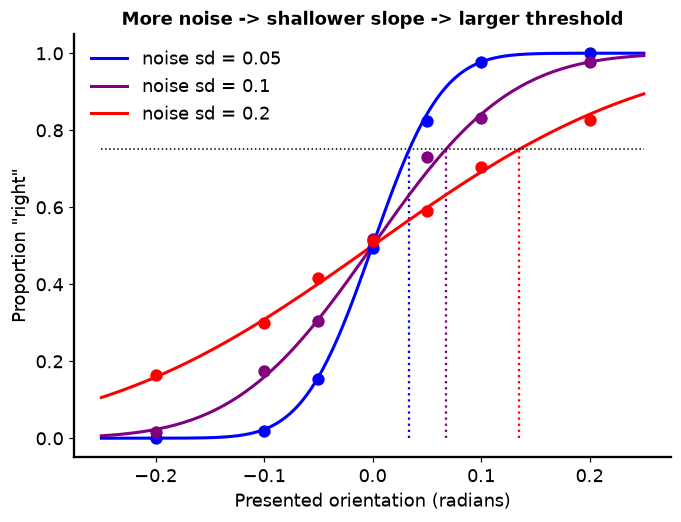

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# How internal noise sets the SLOPE (and threshold) of the psychometric function
signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
noise_sds = [0.05, 0.1, 0.2]   # 👈 try other values
ntrials   = 1000
criterion = 0

rng = np.random.default_rng()
colours = np.column_stack([np.linspace(0,1,len(noise_sds)), np.zeros(len(noise_sds)), np.linspace(1,0,len(noise_sds))])
xs = np.linspace(-0.25, 0.25, 200)

fig, ax = plt.subplots(figsize=(7, 5))
for ni, sd in enumerate(noise_sds):
    samples = rng.standard_normal((ntrials, signal_strengths.size)) * sd + signal_strengths
    pr = (samples > criterion).mean(axis=0)
    ax.scatter(signal_strengths, pr, 50, color=colours[ni], zorder=3)
    ax.plot(xs, norm.cdf(xs, criterion, sd), color=colours[ni], lw=2, label=f"noise sd = {sd}")
    thr = norm.ppf(0.75, criterion, sd)
    ax.plot([thr, thr], [0, 0.75], color=colours[ni], ls=":", lw=1.5)
ax.plot([-0.25, 0.25], [0.75, 0.75], "k:", lw=1)
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title="More noise -> shallower slope -> larger threshold")
ax.legend()
plt.show()
